# #3 Preliminary scRNA-seq tracing data

## Purpose

Analyze preliminary scRNA-seq tracing data for three different speeds (slow, medium, fast). Look at chimarism rate and cell type distribution.

## Setup

In [ ]:
import treedata as td
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import scanpy as sc
import seaborn as sns
import pycea as py
import numpy as np
import harmonypy as hm

from devmap.label_transfer import impute_obs_from_connectivities
from devmap.config import set_theme, get_paths, type_palette, edit_site_palette, edit_palette, lineage_palette
from devmap.utils import load_data, save_plot
from devmap.plots import barplot_with_points, plot_grouped_characters

set_theme()
base_path, plots_path, results_path = get_paths("validation")
embryos_path = base_path / "processing" / "embryos"

## Load data

In [2]:
prelim_tdata = []
characters = []
for embryo in ["slow_r1","slow_r2","medium_r1","medium_r2","fast_r1","fast_r2"]:
    embryo_obs = pd.read_csv(embryos_path / f"{embryo}/{embryo}_droplets.csv", index_col=0)
    embryo_tdata = td.TreeData(obs=embryo_obs.query("type.isin(['donor','host'])"))
    embryo_topology = td.read_h5td(embryos_path / f"{embryo}/{embryo}_tree.h5td")
    for clone, value in embryo_topology.obst.items():
        embryo_tdata.obst[clone] = value
    prelim_tdata.append(embryo_tdata)
    characters.append(embryo_topology.obsm["characters"])
prelim_tdata = td.concat(prelim_tdata)
characters = pd.concat(characters)
characters["embryo"] = characters.index.str.split("-T").str[0]
embryo_characters = {
    key: grp.drop(columns="embryo").notna().any()[lambda s: s].index.tolist()
    for key, grp in characters.groupby("embryo")
}
prelim_tdata.uns["embryo_characters"] = embryo_characters
prelim_tdata.obsm["characters"] = characters.drop(columns="embryo").reindex(prelim_tdata.obs_names).fillna("-")
prelim_tdata.write_h5td(results_path / "prelim_topology.h5td")

/tmp/ipykernel_1218485/2440660022.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  characters["embryo"] = characters.index.str.split("-T").str[0]


## Chimarism rate

In [ ]:
counts = (
    prelim_tdata.obs
    .groupby(['embryo', 'type'], observed=False)
    .size()
    .unstack(fill_value=0)
)
counts = counts.loc[reversed(["SLOW-R1","SLOW-R2","MEDIUM-R1","MEDIUM-R2","FAST-R1","FAST-R2"])]
percent = counts.div(counts.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(1.2,2.4), dpi=600)
percent.plot(kind='barh', stacked=True, color = type_palette, ax = ax)
for container in ax.containers:
    for bar in container:
        bar.set_height(0.8)
# remove legend
ax.legend().remove()
ax.set_xlabel("Percent")
ax.set_xticks([0, 50, 100])
plt.tight_layout()
save_plot(plots_path / "prelim_type_composition.svg", fig, transparent=True)

## Edit fractions

In [5]:
rows = []
for embryo in prelim_tdata.obs.embryo.unique():
    characters = prelim_tdata[prelim_tdata.obs.embryo == embryo].obsm["characters"]
    edit_fracs = {}
    site_names = ["EMX1","HEK3","RNF2"]
    for i, site in enumerate(site_names):
        site_characters = characters.loc[:, characters.columns.str.contains(site)]
        total_missing = (site_characters == "-").sum().sum()
        total_unedited = (site_characters == "*").sum().sum()
        total = site_characters.size
        edit_frac = (total - total_missing - total_unedited) / (total - total_missing)
        edit_fracs[site] = edit_frac
    edit_fracs["embryo"] = embryo
    rows.append(edit_fracs)
edit_fracs = pd.DataFrame(rows)

In [ ]:
edit_fracs_melted = edit_fracs.melt(
    id_vars=["embryo"],
    value_vars=site_names,
    var_name="site",
    value_name="edit_frac",
)
edit_fracs_melted["edit_pct"] = edit_fracs_melted["edit_frac"] * 100
site_name = {"RNF2": "ES1", "HEK3": "ES2", "EMX1": "ES3"}
edit_fracs_melted["site"] = edit_fracs_melted["site"].map(site_name)
edit_fracs_melted["speed"] = (
    edit_fracs_melted["embryo"].str.split("-").str[0].str.capitalize()
)
site_order = ["ES1", "ES2", "ES3"]
edit_fracs_melted["site"] = pd.Categorical(
    edit_fracs_melted["site"],
    categories=site_order,
    ordered=True,
)

fig, ax = plt.subplots(figsize=(2, 2), layout="constrained")
barplot_with_points(
    data=edit_fracs_melted,
    x="speed",
    y="edit_pct",
    hue="site",
    palette=edit_site_palette,
    ax=ax,
    jitter=0,
    point_size=3,
    errorbar=None,
    order=["Slow", "Medium", "Fast"],
)

plt.setp(ax.get_xticklabels(), rotation=90)
ax.set_ylim(0, 100)
ax.set_xlabel("")
ax.set_ylabel("Editing fraction")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

save_plot(plots_path / "prelim_edit_fractions.svg", fig)

## Trees with characters

In [ ]:
for embryo in ["FAST-R2","MEDIUM-R2","SLOW-R1"]:
    fig, ax = plt.subplots(figsize=(3.37,3.37), dpi = 1200)
    embryo_tdata = prelim_tdata[prelim_tdata.obs.embryo == embryo]
    py.pl.branches(embryo_tdata,depth_key ="time", ax = ax, linewidth = .2, legend = False)
    plot_grouped_characters(embryo_tdata,ax = ax,width = .06,label = False,offset = .02)
    save_plot(plots_path / f"{embryo.lower()}_with_characters.svg", fig, rasterize=True)

## Load expression data

In [ ]:
tdata = load_data("log1p_hvg")
medium_tdata = []
for embryo in ["medium_r1","medium_r2"]:
    embryo_tdata = td.read_h5td(embryos_path / f"{embryo}/{embryo}_counts.h5td")
    medium_tdata.append(embryo_tdata)
prelim_tdata = td.concat(medium_tdata)

## Label transfer

In [ ]:
sc.pp.normalize_total(medium_tdata, target_sum=2e4)
sc.pp.log1p(medium_tdata)
sampled_tdata = tdata[tdata.obs.query("stage == 'E9.5'").sample(50000).index].copy()
combined_tdata = td.concat([medium_tdata, sampled_tdata], axis=0)

In [6]:
sc.pp.pca(combined_tdata, n_comps=50)
combined_tdata.obs["prelim"] = combined_tdata.obs.embryo.isin(["MEDIUM-R1", "MEDIUM-R2"]).astype(str)
harmony_out = hm.run_harmony(combined_tdata.obsm["X_pca"], combined_tdata.obs, "prelim")

2026-03-26 15:06:54,620 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-03-26 15:06:54,623 - harmonypy - INFO -   Parameters:
2026-03-26 15:06:54,624 - harmonypy - INFO -     max_iter_harmony: 10
2026-03-26 15:06:54,625 - harmonypy - INFO -     max_iter_kmeans: 20
2026-03-26 15:06:54,626 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-03-26 15:06:54,627 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-03-26 15:06:54,628 - harmonypy - INFO -     nclust: 100
2026-03-26 15:06:54,629 - harmonypy - INFO -     block_size: 0.05
2026-03-26 15:06:54,631 - harmonypy - INFO -     lamb: [1. 1.]
2026-03-26 15:06:54,632 - harmonypy - INFO -     theta: [2. 2.]
2026-03-26 15:06:54,633 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-03-26 15:06:54,634 - harmonypy - INFO -     verbose: True
2026-03-26 15:06:54,635 - harmonypy - INFO -     random_state: 0
2026-03-26 15:06:54,636 - harmonypy - INFO -   Data: 50 PCs × 89765 cells
2026-03-26 15:06:54,637 - harmonypy - INFO

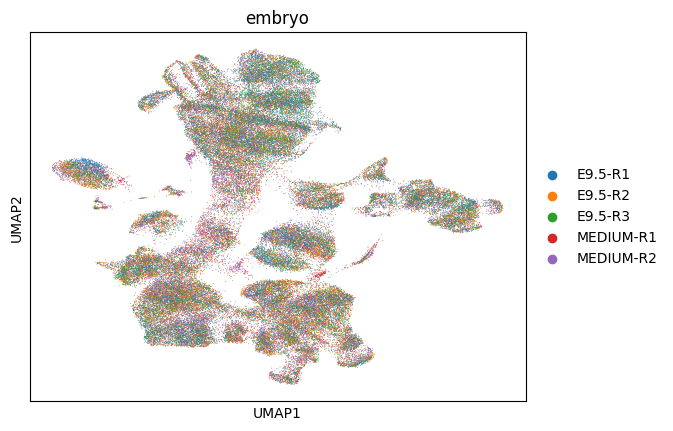

In [ ]:
combined_tdata.obsm["X_harmony"] = harmony_out.Z_corr
sc.pp.neighbors(combined_tdata, n_neighbors=15, n_pcs=50, use_rep="X_harmony")
sc.tl.umap(combined_tdata)
sc.pl.umap(combined_tdata, color="embryo")

In [ ]:
combined_tdata.obs["cell_subtype"] = sampled_tdata.obs["cell_subtype"]
combined_tdata.obs["lineage"] = sampled_tdata.obs["lineage"]
impute_obs_from_connectivities(
    combined_tdata,
    obs_key="lineage",
    connectivity_key="connectivities")
impute_obs_from_connectivities(
    combined_tdata,
    obs_key="cell_subtype",
    connectivity_key="connectivities")
sc.pl.umap(combined_tdata, color="lineage")

## UMAP Embedding

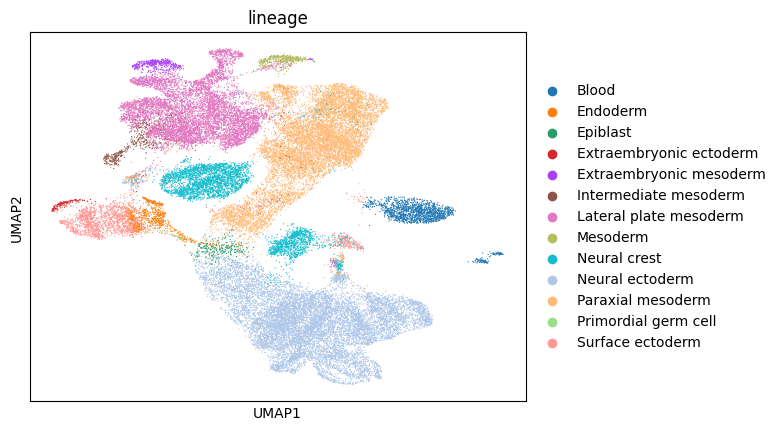

In [ ]:
medium_tdata.obs["lineage"] = combined_tdata.obs["lineage"]
medium_tdata.obs["cell_subtype"] = combined_tdata.obs["cell_subtype"]
medium_tdata.var["highly_variable"] = prelim_tdata.var_names.isin(sampled_tdata.var_names)
sc.pp.pca(medium_tdata, n_comps=50, mask_var="highly_variable")
sc.pp.neighbors(medium_tdata, n_neighbors=15, n_pcs=50)
sc.tl.umap(medium_tdata)
sc.pl.umap(medium_tdata, color="lineage")

In [ ]:
del prelim_tdata.obsp['connectivities']
del prelim_tdata.obsp['distances']
medium_tdata.write_h5td(results_path / "prelim_counts_medium.h5td")

## UMAPs

Donor vs host

In [ ]:
medium_tdata.obs.loc[medium_tdata.obs.lineage == "Blood", "type"] = pd.NA
fig, ax = plt.subplots(figsize=(2.5,2.5), dpi=600)
sc.pl.umap(medium_tdata, color="type", palette=type_palette, frameon = False, s = 2, ax = ax, title = "", sort_order = False)
save_plot(plots_path / "prelim_type_umap.svg", fig, transparent=True, rasterize=True)

Lineage

In [ ]:
fig, ax = plt.subplots(figsize=(2.5,2.5), dpi=600)
sc.pl.umap(medium_tdata, color="lineage", frameon = False, ax = ax, title = "", palette=lineage_palette, sort_order=False)
save_plot(plots_path / "prelim_lineage_umap.svg", fig, transparent=True, rasterize=True)

Clone

In [ ]:
fig, ax = plt.subplots(figsize=(2.5,2.5), dpi=600)
sc.pl.umap(medium_tdata, color="clone", frameon = False, ax = ax, title = "")
save_plot(plots_path / "prelim_clone_umap.svg", fig, transparent=True, rasterize=True)

## Clone lineage composition

In [ ]:
counts = (
    medium_tdata.obs
    .groupby(['clone','lineage'], observed=False)
    .size()
    .unstack(fill_value=0)
    .sort_index(ascending=False)
)
percent = counts.div(counts.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(1.4,2.4), dpi=600)
percent.plot(kind='barh', stacked=True, color = lineage_palette, ax = ax)
for container in ax.containers:
    for bar in container:
        bar.set_height(0.8)
# remove legend
ax.legend().remove()
ax.set_xlabel("Percent")
ax.set_xticks([0, 50, 100])
plt.tight_layout()
save_plot(plots_path / "prelim_lineage_composition.svg", fig, transparent=True)